# Agentic RAG (Tool-Calling Agent)

This notebook builds the simplest of the three agentic RAG patterns in this repo: an
LLM **agent that decides for itself** whether it needs to look anything up before
answering, and which of two knowledge bases (LangGraph docs vs. LangChain docs) to
search.

**Flow:** `agent -> (tool call?) -> retrieve -> grade relevance -> generate -> agent again (more to look up? loop; otherwise finish) or rewrite -> loop`

This version supports **multi-hop** retrieval: after `generate` produces a (possibly partial)
answer, control goes back to `agent` instead of straight to `END`. The agent then decides
whether it still needs another lookup (e.g. the question has a second part that lives in the
other knowledge base) or whether it's done, in which case it takes the same `finish` branch
it always had. A hop counter (`MAX_HOPS`) stops this from looping forever.

Compare this to `2_Corrective_RAG.ipynb` (always retrieves, then corrects with a web
search if the retrieval was bad) and `3_Adaptive_RAG.ipynb` (routes up front between a
vectorstore and the web, then self-checks the final answer for hallucinations).

Run the cells top to bottom. You'll need `GROQ_API_KEY` set — see the README for setup
with `uv`.


## 1. Imports
Everything the notebook needs, grouped by job:
- `requests` + `BeautifulSoup` — scrape the doc pages into plain text
- `langchain_text_splitters`, `langchain_core.documents` — chunk text into `Document` objects
- `langchain_chroma`, `langchain_huggingface` — the vector store and the embedding model
- `langgraph.*` — build the agent as a graph (state, nodes, edges, tool-calling)
- `langchain_groq` — the LLM provider (Groq)

Run this cell first; nothing below it will work without these imports.


In [2]:
import os
from dotenv import load_dotenv
from IPython.display import Image, display
import requests
from bs4 import BeautifulSoup
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import (
    BaseMessage,
    AnyMessage,
    HumanMessage,
    AIMessage,
    SystemMessage
)
from langchain_core.output_parsers import StrOutputParser
from typing import Annotated, get_type_hints, List
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


## 2. Load API keys
`load_dotenv()` reads a local `.env` file and loads its contents as environment
variables. `os.getenv(...)` then pulls `GOOGLE_API_KEY` and `GROQ_API_KEY` out of
those environment variables into Python variables. Keeping keys in `.env` (and out
of the notebook) means they never get committed to git — see `.env.example` for the
file format this expects.


In [3]:
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

## 3. Initialize the LLM
Creates one shared LLM client, `groq_llm`, using Groq's `openai/gpt-oss-120b` model.
`temperature=0` makes it answer as deterministically as possible (same input →
same output), which makes debugging the graph much easier. Every later step —
grading, generating, the agent's own reasoning — calls this same object.


In [4]:
groq_llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="openai/gpt-oss-120b",
    temperature=0
)

## 4. Pick source documentation
Two small sets of URLs: official LangGraph docs and official LangChain docs. These become two separate knowledge bases so the agent can later choose which one is relevant.

In [5]:
langgraph_urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",  
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"  
]

langchain_urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/models",
    "https://docs.langchain.com/oss/python/langchain/tools"
]

## 5. Scrape the LangGraph docs
A plain `requests` + `BeautifulSoup` scrape — good enough for static docs pages
(for JS-heavy sites you'd need a headless browser instead). The next cell fetches
each URL, strips the HTML down to plain text, and stores it with its title and
source URL as a list of dicts in `langgraph_docs`. The cell after that
(`langgraph_docs`) just prints the result so you can eyeball that the scrape
actually worked before moving on.


In [6]:
langgraph_docs = []

headers = {"User-Agent": "Mozilla/5.0"}

for url in langgraph_urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    
    title = soup.title.string.strip() if soup.title else "No title"
    text = soup.get_text(separator="\n", strip=True)
    
    langgraph_docs.append({"source": url, "title": title, "text": text})

In [7]:
langgraph_docs

[{'source': 'https://docs.langchain.com/oss/python/langgraph/overview',
  'title': 'LangGraph overview - Docs by LangChain',
  'text': 'LangGraph overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangGraph overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nLocal server\nChangelog\nThinking in LangGraph\nWorkflows + agents\nCapabilities\nPersistence\nCheckpointers\nStores\nFault tolerance\nEvent streaming\nStreaming\nInterrupts\nTime travel\nMemory\

## 6. Scrape the LangChain docs
Same approach as the last section, run against the second URL list. The following
cell prints `langchain_docs` so you can check it scraped correctly.


In [8]:
langchain_docs = []

headers = {"User-Agent": "Mozilla/5.0"}

for url in langchain_urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    
    title = soup.title.string.strip() if soup.title else "No title"
    text = soup.get_text(separator="\n", strip=True)
    
    langchain_docs.append({"source": url, "title": title, "text": text})

In [9]:
langchain_docs

[{'source': 'https://docs.langchain.com/oss/python/langchain/overview',
  'title': 'LangChain overview - Docs by LangChain',
  'text': 'LangChain overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangChain overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nChangelog\nPhilosophy\nCore components\nAgents\nModels\nMessages\nTools\nShort-term memory\nEvent streaming\nStreaming\nStructured output\nMiddleware\nOverview\nPrebuilt middleware\nCustom middle

## 7. Wrap the LangGraph pages as LangChain `Document` objects
LangChain's downstream tools (splitter, vector store, retriever) all expect a
`Document` object, not a raw dict — so this cell converts each scraped page into
one, keeping the source URL and title in `metadata`. That metadata is what lets
the retriever tool later tell you *where* an answer came from. The next cell
(`langgraph_documents`) just displays the result.


In [10]:
langgraph_documents = []

for lgd in langgraph_docs:
    document = Document(
        page_content=lgd["text"],
        metadata={"source": lgd["source"], "title": lgd["title"]}
    )
    langgraph_documents.append(document)

In [11]:
langgraph_documents

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain'}, page_content='LangGraph overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangGraph overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nLocal server\nChangelog\nThinking in LangGraph\nWorkflows + agents\nCapabilities\nPersistence\nCheckpointers\nStores\nFault tolerance\nEvent streaming\nStreaming\nInterrupts\n

## 8. Wrap the LangChain pages as `Document` objects
Same conversion, for the second knowledge base. The following cell displays the
result.


In [12]:
langchain_documents = []

for lgd in langchain_docs:
    document = Document(
        page_content=lgd["text"],
        metadata={"source": lgd["source"], "title": lgd["title"]}
    )
    langchain_documents.append(document)

In [13]:
langchain_documents

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain'}, page_content='LangChain overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangChain overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nChangelog\nPhilosophy\nCore components\nAgents\nModels\nMessages\nTools\nShort-term memory\nEvent streaming\nStreaming\nStructured output\nMiddleware\nOverview\nPrebuilt middl

## 9. Chunk the documents
Long pages need to be split into smaller pieces before they can be embedded and
searched well — a whole page is too broad for similarity search to be precise.
`RecursiveCharacterTextSplitter` breaks each page into ~1000-character chunks with
200 characters of overlap (so a sentence that straddles a chunk boundary doesn't
get cut in half and lost). The four cells below: split the LangGraph docs and
print the chunk count, then do the same for the LangChain docs.


In [14]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [15]:
langgraph_chunks = text_splitter.split_documents(langgraph_documents)

In [16]:
langgraph_chunks, len(langgraph_chunks)

([Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain'}, page_content="LangGraph overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangGraph overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nLocal server\nChangelog\nThinking in LangGraph\nWorkflows + agents\nCapabilities\nPersistence\nCheckpointers\nStores\nFault tolerance\nEvent streaming\nStreaming\nInterrupts\n

In [17]:
langchain_chunks = text_splitter.split_documents(langchain_documents)

In [18]:
langchain_chunks, len(langchain_chunks)

([Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain'}, page_content="LangChain overview - Docs by LangChain\nDocumentation Index\nFetch the complete documentation index at:\n/llms.txt\nUse this file to discover all available pages before exploring further.\nSkip to main content\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents.\nGet your tickets →\nDocs by LangChain\nhome page\nBuild\nSearch...\n⌘\nK\nAsk AI\nGitHub\nTry LangSmith\nTry LangSmith\nSearch...\nNavigation\nLangChain overview\nOverview\nDeep Agents\nManaged Deep Agents\nLangChain\nLangGraph\nOpenWiki\nIntegrations\nLearn\nReference\nContribute\nPython\nOverview\nGet started\nInstall\nQuickstart\nChangelog\nPhilosophy\nCore components\nAgents\nModels\nMessages\nTools\nShort-term memory\nEvent streaming\nStreaming\nStructured output\nMiddleware\nOverview\nPrebuilt middl

## 10. Create the embedding model
Embeddings turn text into vectors that can be compared for similarity — that's what
makes retrieval possible. This notebook uses `BAAI/bge-m3`, a strong open-source
multilingual model that runs **locally** via `sentence-transformers`, so no extra
API key is needed for this part (it downloads once, from the Hub, then runs on
your own machine/CPU or GPU).

**Other embedding models you could swap in here:**
- `sentence-transformers/all-MiniLM-L6-v2` — much smaller and faster, still local,
  good for quick experiments where top-tier accuracy matters less.
- `BAAI/bge-large-en-v1.5` — another local option; English-only but often more
  accurate than `bge-m3` if you don't need multilingual support.
- `OpenAIEmbeddings(model="text-embedding-3-small")` (from `langchain_openai`) —
  hosted, needs `OPENAI_API_KEY`, no local download or GPU needed, costs a small
  amount per request.
- `GoogleGenerativeAIEmbeddings(model="models/embedding-001")` (from
  `langchain_google_genai`) — hosted, needs `GOOGLE_API_KEY` (already loaded in
  section 2, just unused so far in this notebook).

Swapping any of these in just means replacing the `HuggingFaceEmbeddings(...)` call
below with the equivalent class — everything downstream (`Chroma.from_documents`,
the retrievers, etc.) works the same either way, as long as you re-embed and
rebuild the vector store with the new model.


In [19]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    show_progress=True,
    encode_kwargs={"batch_size": 32}
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

## 11. Build the two vector stores
Each knowledge base gets its own Chroma collection (`langgraph_docs` and
`langchain_docs`), built by embedding every chunk from the previous step. Keeping
them separate is what lets the agent later query just one collection if that's all
a question needs, instead of always searching everything.


In [20]:
langgraph_vectorstore = Chroma.from_documents(
    documents=langgraph_chunks,
    embedding=embedding_model,
    collection_name="langgraph_docs"
)


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [21]:
langchain_vectorstore = Chroma.from_documents(
    documents=langchain_chunks,
    embedding=embedding_model,
    collection_name="langchain_docs"
)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

## 12. Sanity-check the LangGraph collection
Before building anything on top, pull one stored record back out and print its ID,
text, metadata, and raw embedding vector — a quick way to confirm the data actually
landed in Chroma correctly rather than silently failing.


In [22]:
collection = langgraph_vectorstore._collection

print("Collection name:", collection.name)
print("Record count:", collection.count())

data = collection.get(
    limit=1,
    include=["embeddings", "documents", "metadatas"]
)

print("\n--- RECORD ---")

print("\nID:")
print(data["ids"][0])

print("\nDocument:")
print(data["documents"][0])

print("\nMetadata:")
print(data["metadatas"][0])

print("\nEmbedding:")
print(data["embeddings"][0])

Collection name: langgraph_docs
Record count: 117

--- RECORD ---

ID:
2344d1a7-bbf4-4afc-9291-cbdc0eb77568

Document:
LangGraph overview - Docs by LangChain
Documentation Index
Fetch the complete documentation index at:
/llms.txt
Use this file to discover all available pages before exploring further.
Skip to main content
Interrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents.
Get your tickets →
Docs by LangChain
home page
Build
Search...
⌘
K
Ask AI
GitHub
Try LangSmith
Try LangSmith
Search...
Navigation
LangGraph overview
Overview
Deep Agents
Managed Deep Agents
LangChain
LangGraph
OpenWiki
Integrations
Learn
Reference
Contribute
Python
Overview
Get started
Install
Quickstart
Local server
Changelog
Thinking in LangGraph
Workflows + agents
Capabilities
Persistence
Checkpointers
Stores
Fault tolerance
Event streaming
Streaming
Interrupts
Time travel
Memory
Subgraphs
Production
Application structure
Test
Backward compatibil

## 13. Sanity-check the LangChain collection
Same check, run against the second collection.


In [23]:
collection = langchain_vectorstore._collection

print("Collection name:", collection.name)
print("Record count:", collection.count())

data = collection.get(
    limit=1,
    include=["embeddings", "documents", "metadatas"]
)

print("\n--- RECORD ---")

print("\nID:")
print(data["ids"][0])

print("\nDocument:")
print(data["documents"][0])

print("\nMetadata:")
print(data["metadatas"][0])

print("\nEmbedding:")
print(data["embeddings"][0])

Collection name: langchain_docs
Record count: 146

--- RECORD ---

ID:
5141f30a-3c89-4512-81f2-3189b6c22c31

Document:
LangChain overview - Docs by LangChain
Documentation Index
Fetch the complete documentation index at:
/llms.txt
Use this file to discover all available pages before exploring further.
Skip to main content
Interrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents.
Get your tickets →
Docs by LangChain
home page
Build
Search...
⌘
K
Ask AI
GitHub
Try LangSmith
Try LangSmith
Search...
Navigation
LangChain overview
Overview
Deep Agents
Managed Deep Agents
LangChain
LangGraph
OpenWiki
Integrations
Learn
Reference
Contribute
Python
Overview
Get started
Install
Quickstart
Changelog
Philosophy
Core components
Agents
Models
Messages
Tools
Short-term memory
Event streaming
Streaming
Structured output
Middleware
Overview
Prebuilt middleware
Custom middleware
Frontend
Overview
Patterns
Integrations
Advanced usage
Guardrai

## 14. Create retrievers
Wraps each vector store as a retriever configured for similarity search, returning
the top 5 matching chunks per query — one retriever per knowledge base.


In [24]:
langgraph_retriever = langgraph_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

In [25]:
langchain_retriever = langchain_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

## 15. Turn each retriever into an agent tool
This is the key agentic step. Instead of a fixed "always retrieve" pipeline, each
retriever is wrapped in `@tool` with a docstring describing when to use it. The
next cell defines `langgraph_retriever_tool` and `langchain_retriever_tool`: at
runtime, the LLM reads these docstrings and decides for itself whether to call a
tool at all, and if so, which one fits the question.


In [27]:
@tool
def langgraph_retriever_tool(query: str) -> str:
    """Search and return information from the LangGraph documentation.
    Use this for questions about graphs, nodes, state, edges, checkpointing,
    or anything specific to LangGraph."""
    docs = langgraph_retriever.invoke(query)

    results = []
    for doc in docs:
        source = doc.metadata.get("source", "unknown")
        results.append(f"Source: {source}\n{doc.page_content}")

    if len(results) == 0:
        return "No relevant documents found."

    return "\n\n---\n\n".join(results)


@tool
def langchain_retriever_tool(query: str) -> str:
    """Search and return information from the LangChain documentation.
    Use this for questions about chains, prompts, models, LangChain agents,
    or anything specific to LangChain (not LangGraph)."""
    docs = langchain_retriever.invoke(query)

    results = []
    for doc in docs:
        source = doc.metadata.get("source", "unknown")
        results.append(f"Source: {source}\n{doc.page_content}")

    if len(results) == 0:
        return "No relevant documents found."

    return "\n\n---\n\n".join(results)

## 16. Quick manual retrieval test
Calls the LangGraph retriever directly (bypassing the agent) with a test question,
and prints each returned chunk's content and metadata — a sanity check that
retrieval returns something sensible before wiring it into the graph.


In [65]:
docs = langgraph_retriever.invoke("what is langgraph")

for i, doc in enumerate(docs, start=1):
    print("=" * 80)
    print(f"DOCUMENT {i}")
    print("=" * 80)

    print("Content:")
    print(doc.page_content)

    print("\nMetadata:")
    print(doc.metadata)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

DOCUMENT 1
Content:
Time travel
Memory
Subgraphs
Production
Application structure
Test
Backward compatibility
LangSmith Studio
Agent Chat UI
Deployment
LangSmith Observability
Frontend
Overview
Graph execution
Custom stream channels
LangGraph APIs
Graph API
Functional API
Runtime
Studio
On this page
Install
Core benefits
LangGraph ecosystem
Acknowledgements
LangGraph overview
Copy page
Copy page
Gain control with LangGraph to design agents that reliably handle complex tasks
Copy page
Copy page
Trusted by companies shaping the future of agents—including Klarna, Uber, J.P. Morgan, and more—LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents. LangGraph gives you fine-grained control to mix deterministic, hand-coded steps with LLM-driven agentic steps in the same graph, so you can build bespoke agents that behave exactly the way your application requires.
LangGraph is very low-level, and focused entirely on agent


## 17. Bind the tools to the LLM + add a relevance grader
Two separate LLM setups, defined in the next two cells:
- `llm_with_tools` — the main LLM, given access to both retriever tools via
  `bind_tools`, so it can call one when it needs to.
- `llm_grading` — a second LLM call with structured output (a `grade` model with a
  `binary_score` field), used later to score whether retrieved documents actually
  answer the question.


In [66]:
tools = [langgraph_retriever_tool, langchain_retriever_tool]

llm_with_tools = groq_llm.bind_tools(tools)

In [67]:
class grade(BaseModel):
    """Binary score for relevance check."""

    binary_score: str = Field(description="Relevance score 'yes' or 'no'")
    
llm_grading = groq_llm.with_structured_output(grade)

## 18. Define the graph state
The graph's shared memory: a `messages` list (using LangGraph's standard `add_messages`
reducer, so new messages get appended rather than overwriting the whole list), a `hops`
counter, and `last_answer`. `hops` tracks how many times the `agent` node has run, so the
router can force the graph to finish after `MAX_HOPS` rounds instead of retrieving forever.
`last_answer` is a small robustness addition: both `generate` (after synthesizing from
freshly retrieved context) and `agent` (when it decides to finish instead of calling another
tool) write their answer here. Whichever of the two nodes actually produces the true final
answer on a given run, `last_answer` ends up holding it -- so you don't have to guess which
one to trust (open-weight models can be inconsistent about which step finalizes the answer).


In [68]:
class State(BaseModel):
    messages: Annotated[List[BaseMessage], add_messages] = []
    hops: int = 0
    last_answer: str = ""


## 19. Define the graph nodes
Split into three cells so the pieces are easy to tell apart:

1. **Constants** — `MAX_HOPS` (hop cap) and `SYSTEM_PROMPT` (tells the model it may call a
   retriever tool more than once if the question has parts that live in different
   knowledge bases). `agent` prepends this on the fly; it's never written into
   `state.messages`, so `messages[0]` stays the original `HumanMessage` no matter how many
   hops happen.
2. **Node functions** (`agent`, `grade_documents`, `generate`, `rewrite`) — the actual
   steps the graph moves through.
3. **Router function** (`router`) — kept separate since it plays a different role: it
   doesn't do work, it just reads the state and decides where to go next (another
   retrieval, or finish). It also enforces `MAX_HOPS` so a question can't bounce between
   `agent` and the retriever indefinitely.


In [79]:
MAX_HOPS = 5

SYSTEM_PROMPT = SystemMessage(content="""You are a documentation assistant with two search tools: one over the \
LangGraph docs, one over the LangChain docs. Some questions only need one lookup. Others have multiple parts \
that live in different places -- for those, call a tool, look at what came back, and if part of the question is \
still unanswered, call a tool again (the same one or the other one) with a focused follow-up query that targets \
just the missing part. Only stop calling tools once you can fully answer every part of the question. Don't call \
a tool again just to double-check an answer you're already confident in.

When you decide NOT to call another tool, your response IS the final answer shown to the user. In that case, \
review the whole conversation so far -- including any draft answers already produced from retrieved context -- \
and write out the complete, synthesized final answer yourself. Never reply with "I don't know" or a placeholder \
if the tool results already gathered in this conversation contain what's needed to answer.""")


def agent(state: State):
    """
    Invoke the agent model to generate a response based on the current state. Given the
    question (and, on later hops, what's been retrieved and answered so far), it decides
    whether to retrieve using a retriever tool or to finish.

    Args:
        current state messages

    Return:
        dict: updated state with the agent's response appended and the hop counter
        incremented. If the agent is finishing (no tool call in this response), also
        updates `last_answer` with the agent's own closing message, so `last_answer`
        reflects whichever node -- `generate` or `agent` -- actually produced the true
        final answer on this run.
    """
    print("---CALL AGENT---")
    messages = state.messages

    has_system_message = False
    for m in messages:
        if isinstance(m, SystemMessage):
            has_system_message = True
            break

    if not has_system_message:
        messages = [SYSTEM_PROMPT] + messages

    response = llm_with_tools.invoke(messages)

    update = {
        "messages": [response],
        "hops": state.hops + 1,
    }

    is_finishing = False
    if not response.tool_calls:
        is_finishing = True

    if is_finishing:
        update["last_answer"] = response.content

    return update


def grade_documents(state: State) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    prompt = ChatPromptTemplate.from_template(
        """Decide whether the retrieved passage below is actually useful for answering the question. \n 
        Retrieved passage: \n\n {context} \n\n
        Question: {question} \n
        Count it as relevant if it overlaps with the question either in specific keywords or in overall meaning. \n
        """
    )

    chain = prompt | llm_grading

    messages = state.messages
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"


def generate(state: State):
    """
    Generate an answer from the most recently retrieved documents, then hand control back
    to the agent so it can decide whether another hop is needed. Also stashes the answer in
    `last_answer` so the graph's most recently synthesized answer is always recoverable, even
    if a later `agent` hop produces a weak closing message instead of repeating it.

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state.messages
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    prompt = ChatPromptTemplate.from_template(
        """
        The user's question may have multiple parts, possibly answered by separate lookups.
        Using ONLY the context below, answer whatever part of the question this context
        actually addresses. If this context doesn't address any part of the question,
        say so briefly — don't say "I don't know" about the whole question.

        Question: {question}
        Context: {context}
        Answer:
        """
    )

    rag_chain = prompt | groq_llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {
        "messages": AIMessage(content=response),
        "last_answer": response,
    }


def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state.messages
    question = messages[0].content

    prompt = ChatPromptTemplate.from_template(
        """ \n 
    Rewrite the question below so it retrieves better matches, focusing on the intent behind it rather than the exact original wording. \n 
    Original question:
    \n ------- \n
    {question} 
    \n ------- \n
    Improved question: """
    )

    rewrite_chain = prompt | groq_llm

    response = rewrite_chain.invoke({"question": question})

    return {
        "messages": [response]
    }



In [80]:
def router(state: State) -> Literal["use_tool", "finish"]:
    """
    Decides whether the agent's last message needs a tool call, or whether the graph
    should stop. Also enforces MAX_HOPS so a question can't retrieve forever.

    Args:
        state: The current state

    Returns:
        str: "use_tool" to go retrieve again, "finish" to end the run
    """
    last_message = state.messages[-1]

    if state.hops >= MAX_HOPS:
        print(f"---HOP LIMIT REACHED ({state.hops}) -- FORCING FINISH---")
        return "finish"

    if last_message.tool_calls:
        return "use_tool"
    else:
        return "finish"


## 20. Assemble the graph
Wires the nodes together with `add_node` and `add_edge`/`add_conditional_edges`: start at
`Agent`, and let it loop through a retrieve → grade → generate → agent cycle. The key
change from a single-hop graph: `"Generate"` now points back to `"Agent"` instead of
straight to `END`. `Agent`'s existing conditional edges already cover both outcomes of
that return trip — `router` sends it to `"Retriver"` again if the model wants another
lookup (`"use_tool"`), or to `END` if it's done (`"finish"`) — so no separate
`Agent -> END` edge needs to be added on top of the conditional ones.


In [81]:
workflow = StateGraph(State)

workflow.add_node("Agent", agent)
workflow.add_node("Retriver", ToolNode(tools))
workflow.add_node("Rewrite", rewrite)
workflow.add_node("Generate", generate)

workflow.add_edge(START, "Agent")
workflow.add_conditional_edges("Agent", router, {"use_tool": "Retriver", "finish": END})
workflow.add_conditional_edges("Retriver", grade_documents, {"generate": "Generate", "rewrite": "Rewrite"})
workflow.add_edge("Generate", "Agent")
workflow.add_edge("Rewrite", "Agent")


## 21. Compile and visualize
`workflow.compile()` turns the wiring into a runnable graph. Rendering it as a
Mermaid diagram (`draw_mermaid_png`) is the fastest way to sanity-check that the
nodes and edges connect the way you intended, before running a real question
through it.


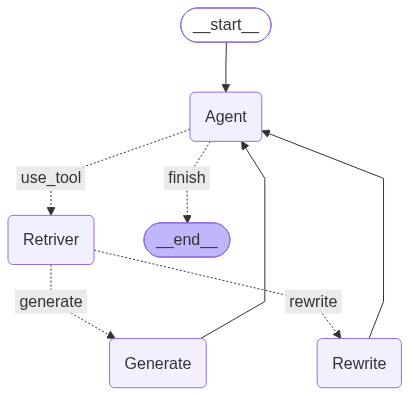

In [82]:
workflow_builder = workflow.compile()

display(Image(workflow_builder.get_graph().draw_mermaid_png()))

## 22. Single-hop example
A question that's fully answerable from one knowledge base in one retrieval. Expect the
console trace to look like: `CALL AGENT` → `CHECK RELEVANCE` → `GENERATE` → `CALL AGENT`
(no tool call this time, since it already has what it needs) → done. Watch for the second
`---CALL AGENT---` — that's the new loop-back happening, it just resolves to `finish`
immediately here.

`result["messages"][-1].content` is technically "the final message," but it's whatever the
`agent` node's closing reply was -- print `result["last_answer"]` too (set by `generate`) to
see the actual synthesized answer, since the two can occasionally diverge (see section 18).


In [83]:
single_hop_question = [HumanMessage(content="What are the core components of the LangChain docs?")]


In [84]:
result = workflow_builder.invoke({"messages": single_hop_question})
result


---CALL AGENT---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---
---CALL AGENT---


{'messages': [HumanMessage(content='What are the core components of the LangChain docs?', additional_kwargs={}, response_metadata={}, id='77d9a641-ef99-46e4-81bc-28c42a9407d1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What are the core components of the LangChain docs?" Likely they want an overview of core components in LangChain documentation: maybe sections like "LLMs", "Prompts", "Chains", "Agents", "Memory", "Tools", "Callbacks", "Schemas", "Utilities". We need to retrieve from LangChain docs. Use the LangChain retriever tool with query "core components of the LangChain docs".', 'tool_calls': [{'id': 'fc_dff56097-8cc2-4119-b1ba-575f09d81a38', 'function': {'arguments': '{"query":"core components of the LangChain documentation"}', 'name': 'langchain_retriever_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 422, 'total_tokens': 549, 'completion_time': 0.267498703, 'completion_tokens_d

In [85]:
print(result["last_answer"])

The LangChain documentation groups its functionality into a set of **core components**. These are:

- **Agents** – orchestrate LLM calls, tools, and decision‑making logic.  
- **Models** – wrappers around language models, chat models, embeddings, etc.  
- **Messages** – the data structures used to represent prompts, responses, and chat history.  
- **Tools** – external utilities (APIs, functions, etc.) that agents can invoke.  
- **Short‑term memory** – transient state that agents can read/write during a single run.  
- **Event streaming** – mechanisms for emitting and handling events as a chain or agent executes.  
- **Streaming** – support for token‑by‑token generation from LLMs.  
- **Structured output** – utilities for parsing LLM responses into well‑defined data structures.  
- **Middleware** – pluggable components that can intercept, modify, or augment the behavior of chains, agents, or models.


## 23. Multi-hop example
A question with two parts that live in *different* knowledge bases. If the system prompt
does its job, expect: `CALL AGENT` → `CHECK RELEVANCE` → `GENERATE` (answers part 1) →
`CALL AGENT` again (notices part 2 is still open, calls the other retriever tool) →
`CHECK RELEVANCE` → `GENERATE` (answers part 2) → `CALL AGENT` (finish) → done.

This isn't guaranteed on every run — it's the LLM deciding, at each `agent` step, whether
it still needs more information, so it can also decide one retrieval was already enough.
`MAX_HOPS = 5` (set in section 19) caps how many times `agent` can loop back in, so even a
model that keeps calling tools will be forced to finish rather than loop forever.

Same note as the single-hop example: check `result["last_answer"]` alongside the raw message
list. It now reflects whichever node produced the true final answer -- either the most recent
`generate` call, or `agent`'s own closing synthesis if that's the one that actually finished
the job. Earlier versions of this notebook only had `generate` update `last_answer`, which
meant a run where `generate` said "I don't know" early and `agent` synthesized the real answer
on a later hop would leave `last_answer` stuck on the stale "I don't know" -- that's fixed now
by having `agent` also update `last_answer` when it finishes.


In [86]:
multi_hop_question = [HumanMessage(content=(
    "I'm deciding between LangGraph's graph API and LangChain's built-in agents for a "
    "new project. Using details from both docs, explain how a LangGraph StateGraph "
    "differs from a LangChain agent's tool-calling loop."
))]


In [87]:
result = workflow_builder.invoke({"messages": multi_hop_question})
result


---CALL AGENT---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---
---CALL AGENT---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---
---CALL AGENT---


{'messages': [HumanMessage(content="I'm deciding between LangGraph's graph API and LangChain's built-in agents for a new project. Using details from both docs, explain how a LangGraph StateGraph differs from a LangChain agent's tool-calling loop.", additional_kwargs={}, response_metadata={}, id='981743e3-1ac3-4ee1-8e5c-56a2f7f26fd6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to compare LangGraph StateGraph vs LangChain agent's tool-calling loop. Need info from both docs. We'll search LangGraph docs for StateGraph.", 'tool_calls': [{'id': 'fc_a0d1a59e-9395-4ebe-8700-83ef5221a85a', 'function': {'arguments': '{"query":"StateGraph"}', 'name': 'langgraph_retriever_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 456, 'total_tokens': 522, 'completion_time': 0.140357182, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.021473727, 'prompt_tokens_details': None, 'queue_time': 0.0519

In [88]:
print(result["last_answer"])


**Short answer**

- **LangGraph `StateGraph`** is a *graph‑oriented* workflow engine.  You define a **state schema** (a typed dict) that is passed from node to node, and you wire together **nodes** and **edges** (including conditional edges, “send” commands, sub‑graphs, etc.).  Execution follows the graph topology, can branch, loop, run in parallel, and can be **checkpointed / resumed** at any step.  The graph itself is the “program” – the control‑flow logic lives in the graph, not in the model.

- **LangChain’s built‑in agents** implement a **linear tool‑calling loop**.  The LLM (the “agent”) receives a list of messages, decides whether it needs to call a tool, emits one or more `tool_calls`, you execute those tools, append the tool results as new messages, and feed the updated message list back to the model.  The loop repeats until the model returns a final answer.  The control‑flow logic lives inside the LLM’s reasoning; the surrounding code only orchestrates the “call‑tool‑append‑r